In [1]:
import os
import glob
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

device = torch.device('cpu')
torch.manual_seed(0)
random.seed(0)

In [ ]:
class LiteDenseBlock(nn.Module):
    def __init__(self, num_channel=32, growth_channel=8):
        super().__init__()
        self.conv1 = nn.Conv2d(num_channel, growth_channel, 3, 1, 1)
        self.conv2 = nn.Conv2d(num_channel + growth_channel * 1, growth_channel, 3, 1, 1)
        self.conv3 = nn.Conv2d(num_channel + growth_channel * 2, growth_channel, 3, 1, 1)
        self.conv4 = nn.Conv2d(num_channel + growth_channel * 3, num_channel, 3, 1, 1)
        self.lrelu = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x):
        x1 = self.lrelu(self.conv1(x))
        x2 = self.lrelu(self.conv2(torch.cat((x, x1), 1)))
        x3 = self.lrelu(self.conv3(torch.cat((x, x1, x2), 1)))
        x4 = self.conv4(torch.cat((x, x1, x2, x3), 1))
        return x + x4 * 0.2


class LiteESRGANGenerator(nn.Module):
    def __init__(self, num_channel=32, growth_channel=8, num_blocks=6, in_channels=1):
        super().__init__()
        self.conv_first = nn.Conv2d(in_channels, num_channel, 3, 1, 1)
        self.body = nn.Sequential(*[LiteDenseBlock(num_channel, growth_channel) for _ in range(num_blocks)])
        self.conv_after_body = nn.Conv2d(num_channel, num_channel, 3, 1, 1)
        self.conv_last = nn.Conv2d(num_channel, in_channels, 3, 1, 1)

    def forward(self, x):
        feat_first = self.conv_first(x)
        feat = self.conv_after_body(self.body(feat_first)) + feat_first
        residual = self.conv_last(feat)
        return x + residual  # conexión residual global: salida = entrada + corrección aprendida


def count_parameters(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

In [12]:
class PairedGraySRDataset(Dataset):
    def __init__(self, pairs, img_size=(112, 92)):
        self.pairs = pairs
        self.h, self.w = img_size  # solo se usa para verificar consistencia, no para degradar
        self.to_tensor = transforms.ToTensor()

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        lr_path, hr_path = self.pairs[idx]
        hr = Image.open(hr_path).convert('L')
        lr = Image.open(lr_path).convert('L')

        # Aseguramos que midan exactamente lo mismo, SIN encoger nada.
        # Si ya vienen en 112x92 esto no cambia nada (resize a su propio tamaño).
        if hr.size != (self.w, self.h):
            hr = hr.resize((self.w, self.h), Image.BICUBIC)
        if lr.size != (self.w, self.h):
            lr = lr.resize((self.w, self.h), Image.BICUBIC)

        return self.to_tensor(lr), self.to_tensor(hr)

In [18]:
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms

# =====================================================
# RUTAS
# =====================================================

DATASET_PATH = Path("../dataset")

CLEAN_DIR = DATASET_PATH / "ORL_Limpio"
DEGRADACION_DIR = DATASET_PATH / "Degradacion"

SCALE = 4  # 2 o 4 -> selecciona ORL_escala2 u ORL_escala4
IMG_SIZE = (112, 92)  # (alto, ancho)

DEGRADED_DIR = DEGRADACION_DIR / f"ORL_escala{SCALE}"

EXTENSIONES_VALIDAS = [".pgm", ".png", ".jpg", ".jpeg", ".bmp"]


def _buscar_por_stem(carpeta: Path, stem: str):
    for ext in EXTENSIONES_VALIDAS:
        candidato = carpeta / f"{stem}{ext}"
        if candidato.is_file():
            return candidato
    return None


def list_pairs(clean_split_dir: Path, degraded_split_dir: Path):
    pairs = []
    subject_dirs = sorted(d for d in clean_split_dir.glob("s*") if d.is_dir())
    for clean_subj_dir in subject_dirs:
        subject_name = clean_subj_dir.name
        degraded_subj_dir = degraded_split_dir / subject_name
        assert degraded_subj_dir.is_dir(), f"Falta carpeta degradada: {degraded_subj_dir}"

        clean_files = sorted(
            f for f in clean_subj_dir.glob("*.*") if f.suffix.lower() in EXTENSIONES_VALIDAS
        )
        for clean_path in clean_files:
            degraded_path = _buscar_por_stem(degraded_subj_dir, clean_path.stem)
            assert degraded_path is not None, (
                f"Falta par degradado para: {clean_path.name} en {degraded_subj_dir}"
            )
            pairs.append((degraded_path, clean_path))
    return pairs


class PairedGraySRDataset(Dataset):
    """
    SIN degradación adicional: tus LR y HR ya vienen ambas en 92x112.
    Solo convierte a tensor; el resize es un fallback por si algún
    archivo puntual no coincidiera exactamente en tamaño.
    """
    def __init__(self, pairs, img_size=(112, 92)):
        self.pairs = pairs
        self.h, self.w = img_size  # alto, ancho
        self.to_tensor = transforms.ToTensor()

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        lr_path, hr_path = self.pairs[idx]
        hr = Image.open(hr_path).convert('L')
        lr = Image.open(lr_path).convert('L')

        target_size = (self.w, self.h)  # PIL usa (ancho, alto)
        if hr.size != target_size:
            hr = hr.resize(target_size, Image.BICUBIC)
        if lr.size != target_size:
            lr = lr.resize(target_size, Image.BICUBIC)

        return self.to_tensor(lr), self.to_tensor(hr)


# --- Construcción de pares y datasets ---
train_pairs = list_pairs(CLEAN_DIR / "Training", DEGRADED_DIR / "Training")
test_pairs = list_pairs(CLEAN_DIR / "Testing", DEGRADED_DIR / "Testing")

train_ds = PairedGraySRDataset(train_pairs, img_size=IMG_SIZE)
val_ds = PairedGraySRDataset(test_pairs, img_size=IMG_SIZE)
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)

print(f"Training pairs: {len(train_ds)}  (esperado 360)")
print(f"Testing pairs:  {len(val_ds)}  (esperado 40)")

Training pairs: 360  (esperado 360)
Testing pairs:  40  (esperado 40)


In [ ]:
import time
from torch.utils.data import DataLoader

BATCH_SIZE = 16
EPOCHS = 100
LR_INIT = 3e-4
STEP_SIZE = 30
GAMMA = 0.5
PRINT_EVERY = 10

CHECKPOINT_PATH = Path("../model_lite") / f"literestorenet_escala{SCALE}_best.pth"
CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

model = LiteESRGANGenerator(num_channel=32, growth_channel=8, num_blocks=6, in_channels=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR_INIT)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=STEP_SIZE, gamma=GAMMA)
l1_loss = nn.L1Loss()


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, n = 0.0, 0
    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for lr_img, hr_img in loader:
            lr_img, hr_img = lr_img.to(device), hr_img.to(device)
            if train:
                optimizer.zero_grad()
            pred = model(lr_img)
            loss = l1_loss(pred, hr_img)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * lr_img.size(0)
            n += lr_img.size(0)
    return total_loss / n


print("Iniciando entrenamiento...")
print(f"   Épocas   : {EPOCHS}")
print(f"   Batch    : {BATCH_SIZE}")
print(f"   LR init  : {LR_INIT}")
print(f"   Scheduler: StepLR(step={STEP_SIZE}, γ={GAMMA})")
print("─" * 64)

best_val_loss = float('inf')
t_start = time.time()

for epoch in range(1, EPOCHS + 1):
    t_epoch = time.time()
    train_loss = run_epoch(train_loader, train=True)
    val_loss = run_epoch(val_loader, train=False)
    scheduler.step()
    elapsed = time.time() - t_epoch

    guardado = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'model_state_dict': model.state_dict(),
            'epoch': epoch,
            'val_loss': val_loss,
            'scale': SCALE,
        }, CHECKPOINT_PATH)
        guardado = "  ✦ guardado"

    if epoch == 1 or epoch % PRINT_EVERY == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Época [{epoch:3d}/{EPOCHS}]  train: {train_loss:.6f}  val: {val_loss:.6f}  "
              f"lr: {current_lr:.2e}  t: {elapsed:.0f}s{guardado}")

total_elapsed = time.time() - t_start
print("─" * 64)
print(f" Entrenamiento completado en {total_elapsed:.1f} s")
print(f" Mejor val loss: {best_val_loss:.6f}  →  {CHECKPOINT_PATH.name}")

Iniciando entrenamiento...
   Épocas   : 100
   Batch    : 16
   LR init  : 0.0003
   Scheduler: StepLR(step=30, γ=0.5)
────────────────────────────────────────────────────────────────
Época [  1/100]  train: 0.180375  val: 0.100461  lr: 3.00e-04  t: 29s  ✦ guardado
Época [ 10/100]  train: 0.068522  val: 0.067027  lr: 3.00e-04  t: 27s  ✦ guardado
Época [ 20/100]  train: 0.065691  val: 0.066248  lr: 3.00e-04  t: 27s
Época [ 30/100]  train: 0.062198  val: 0.060348  lr: 1.50e-04  t: 28s  ✦ guardado
Época [ 40/100]  train: 0.060552  val: 0.062034  lr: 1.50e-04  t: 27s
Época [ 50/100]  train: 0.059793  val: 0.059171  lr: 1.50e-04  t: 32s
Época [ 60/100]  train: 0.058646  val: 0.057507  lr: 7.50e-05  t: 31s  ✦ guardado
Época [ 70/100]  train: 0.058276  val: 0.057752  lr: 7.50e-05  t: 31s
Época [ 80/100]  train: 0.058603  val: 0.057246  lr: 7.50e-05  t: 31s
Época [ 90/100]  train: 0.057601  val: 0.056920  lr: 3.75e-05  t: 32s
Época [100/100]  train: 0.057351  val: 0.056245  lr: 3.75e-05  t: 3

In [20]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"Pesos cargados desde época {checkpoint['epoch']}  (val_loss={checkpoint['val_loss']:.6f})")

Pesos cargados desde época 100  (val_loss=0.056245)


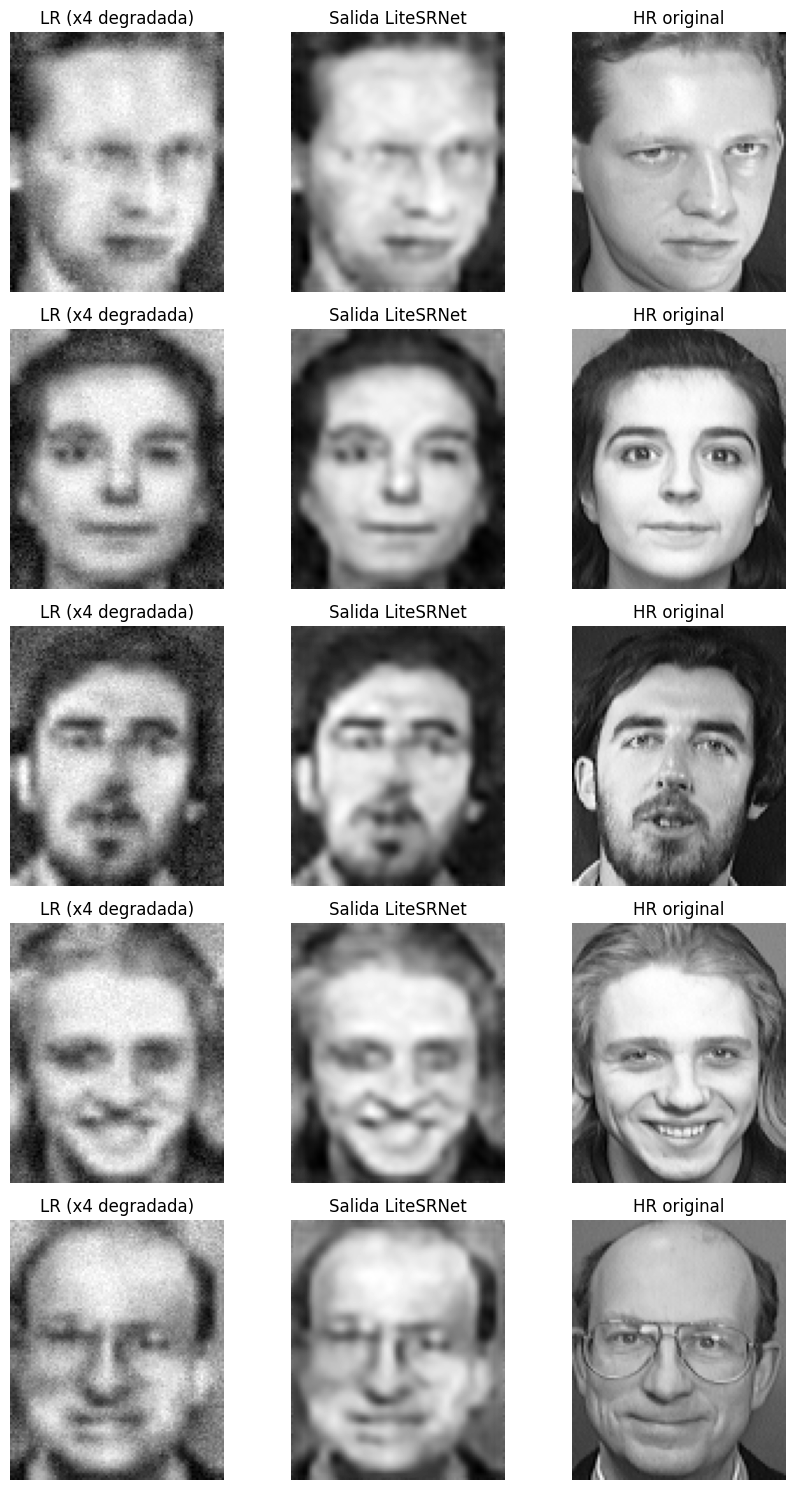

In [21]:
def tensor_to_np(t):
    return t.squeeze().detach().cpu().numpy()

model.eval()
n_examples = 5
fig, axes = plt.subplots(n_examples, 3, figsize=(9, 3 * n_examples))

with torch.no_grad():
    for i in range(n_examples):
        lr_img, hr_img = val_ds[i]
        pred = model(lr_img.unsqueeze(0).to(device))

        axes[i, 0].imshow(tensor_to_np(lr_img), cmap='gray')
        axes[i, 0].set_title(f'LR (x{SCALE} degradada)')
        axes[i, 1].imshow(tensor_to_np(pred), cmap='gray')
        axes[i, 1].set_title('Salida LiteSRNet')
        axes[i, 2].imshow(tensor_to_np(hr_img), cmap='gray')
        axes[i, 2].set_title('HR original')
        for ax in axes[i]:
            ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from tqdm import tqdm
import os
import cv2
import numpy as np
import torch

# Directorios

#INPUT_DIR_Training  = "../../dataset/Degradacion/ORL_escala4/Training"
#OUTPUT_DIR_Training = "../../dataset/Tecnica De mejora de imagen/ORL_LiteESRGAN_x4/Training"

INPUT_DIR_Testing  = "../../dataset/Degradacion/ORL_escala4/Testing"
OUTPUT_DIR_Testing = "../../dataset/Tecnica De mejora de imagen/ORL_LiteESRGAN_x4/Testing"

os.makedirs(OUTPUT_DIR_Testing, exist_ok=True)

model = LiteESRGANGenerator(num_channel=32, growth_channel=8, num_blocks=6, in_channels=1).to(device)

checkpoint = torch.load(
    "literestorenet_escala4_best.pth",
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

LiteRestoreNet(
  (conv_first): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (body): Sequential(
    (0): LiteDenseBlock(
      (conv1): Conv2d(32, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(40, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv3): Conv2d(48, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv4): Conv2d(56, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (lrelu): LeakyReLU(negative_slope=0.2, inplace=True)
    )
    (1): LiteDenseBlock(
      (conv1): Conv2d(32, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(40, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv3): Conv2d(48, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv4): Conv2d(56, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (lrelu): LeakyReLU(negative_slope=0.2, inplace=True)
    )
    (2): LiteDenseBlock(
      (conv1): Conv2d(32, 8, kerne

In [9]:
imagenes = []

for root, dirs, files in os.walk(INPUT_DIR_Testing):

    for file in files:

        if file.lower().endswith((".png", ".pgm", ".jpg", ".jpeg", ".bmp")):

            imagenes.append(
                os.path.join(root, file)
            )

print(f"Imágenes encontradas: {len(imagenes)}")

Imágenes encontradas: 40


# Generación del dataset Lite Esrgan Testing

In [10]:
# ============================
# Generar reconstrucción LiteSRNet escala x4
# ============================

with torch.no_grad():

    for ruta_img in tqdm(imagenes):

        img = cv2.imread(
            ruta_img,
            cv2.IMREAD_GRAYSCALE
        )

        img = img.astype(np.float32) / 255.0

        tensor = (
            torch.from_numpy(img)
            .unsqueeze(0)
            .unsqueeze(0)
            .to(device)
        )

        sr = model(tensor)

        sr = torch.clamp(sr, 0.0, 1.0)

        sr = sr.squeeze().cpu().numpy()

        sr = (sr * 255).astype(np.uint8)

        # ============================
        # Mantener estructura s1,s2,...
        # ============================

        relative_path = os.path.relpath(
            ruta_img,
            INPUT_DIR_Testing
        )

        save_path = os.path.join(
            OUTPUT_DIR_Testing,
            relative_path
        )

        os.makedirs(
            os.path.dirname(save_path),
            exist_ok=True
        )

        cv2.imwrite(save_path, sr)

print("\nDataset LiteSRNet Testing escala x4 Testing generado correctamente.")
print(f"Total imágenes: {len(imagenes)}")
print(f"Guardado en: {OUTPUT_DIR_Testing}")

100%|██████████| 40/40 [00:01<00:00, 32.00it/s]


Dataset LiteSRNet Testing escala x4 Testing generado correctamente.
Total imágenes: 40
Guardado en: ../dataset/Tecnica De mejora de imagen/ORL_LiteSRNet_x4/Testing


# Generación del dataset Lite Esrgan Training

In [ ]:
# ============================
# Generar reconstrucción LiteSRNet escala x4
# ============================

with torch.no_grad():

    for ruta_img in tqdm(imagenes):

        img = cv2.imread(
            ruta_img,
            cv2.IMREAD_GRAYSCALE
        )

        img = img.astype(np.float32) / 255.0

        tensor = (
            torch.from_numpy(img)
            .unsqueeze(0)
            .unsqueeze(0)
            .to(device)
        )

        sr = model(tensor)

        sr = torch.clamp(sr, 0.0, 1.0)

        sr = sr.squeeze().cpu().numpy()

        sr = (sr * 255).astype(np.uint8)

        # ============================
        # Mantener estructura s1,s2,...
        # ============================

        relative_path = os.path.relpath(
            ruta_img,
            INPUT_DIR_Training
        )

        save_path = os.path.join(
            OUTPUT_DIR_Training,
            relative_path
        )

        os.makedirs(
            os.path.dirname(save_path),
            exist_ok=True
        )

        cv2.imwrite(save_path, sr)

print("\nDataset LiteSRNet Testing escala x4 Training generado correctamente.")
print(f"Total imágenes: {len(imagenes)}")
print(f"Guardado en: {OUTPUT_DIR_Training}")

100%|██████████| 360/360 [00:10<00:00, 32.78it/s]


Dataset LiteSRNet Testing escala x4 Training generado correctamente.
Total imágenes: 360
Guardado en: ../dataset/Tecnica De mejora de imagen/ORL_LiteSRNet_x4/Training
